<a href="https://colab.research.google.com/github/universevision/College-Project-BY-Om-Kumar/blob/Minor-1-Project/Bus_Route_Efficiency_Analysis_By_Om_Kumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#####**Bus Route Efficiency Analysis**

**Importing all esentiaal libraries.**

1.   Numpy - For Calculations
2.   Pandas - For Using Data
3.   Matplotlib - For Graphs
4.   Seaborn - For More Advance Graph

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

Creating 'data' variable to store our dataset/csv file

In [4]:
data = pd.read_csv("/content/bus_route_efficiency_minor1_v2.csv")
data.head()

,TripID,RouteID,StopID,StopName,WeekBeginning,NumberOfBoardings
0,30025,680,20105,Industrial Area,2013-08-18,30
1,30067,315,20077,Main Bus Stand,2013-07-28,12
2,30103,420,20024,Old Town Stop,2013-06-30,38
3,30092,315,20067,Central Station,2013-08-25,32
4,30142,315,20135,Central Station,2013-09-08,59


changing Data type of'WeekBeginning' From Object To Datetime Datatype.

In [5]:
data['WeekBeginning'] = pd.to_datetime(data['WeekBeginning'])

then we confirm all the data type is like our required data type by showing data information.

In [6]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TripID             100 non-null    int64         
 1   RouteID            100 non-null    int64         
 2   StopID             100 non-null    int64         
 3   StopName           100 non-null    object        
 4   WeekBeginning      100 non-null    datetime64[ns]
 5   NumberOfBoardings  100 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 4.8+ KB


,TripID,RouteID,StopID,WeekBeginning,NumberOfBoardings
count,100.000000,100.000000,100.000000,100,100.000000
mean,30074.430000,427.650000,20076.950000,2013-08-09 14:24:00,32.410000
min,30000.000000,210.000000,20004.000000,2013-06-30 00:00:00,1.000000
25%,30035.000000,315.000000,20037.000000,2013-07-21 00:00:00,18.000000
50%,30070.000000,420.000000,20081.000000,2013-08-11 00:00:00,33.000000
75%,30117.250000,550.000000,20113.750000,2013-09-01 00:00:00,47.250000
max,30149.000000,680.000000,20149.000000,2013-09-15 00:00:00,59.000000
std,44.923112,173.366044,43.765531,NaN,17.694429


**Top 5 most boardings Route** -- We group the Route with same RouteID and Sum the Number Of Boardings on that RouteID Routes,then we store this value in 'route_load' Variable.
then we print that variable --


In [7]:
route_load = data.groupby('RouteID')['NumberOfBoardings'].sum()
route_load

,NumberOfBoardings
RouteID,
210,596
315,811
420,640
550,503
680,691


we present the route_load variable in a graph

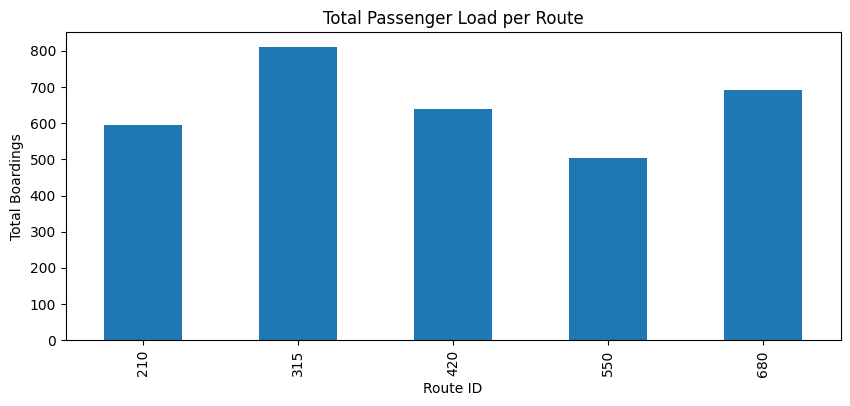

In [8]:
route_load.plot(kind='bar', figsize=(10,4))
plt.title("Total Passenger Load per Route")
plt.xlabel("Route ID")
plt.ylabel("Total Boardings")
plt.show()


**Top 10 Most Boarding Stops**

In [9]:
stop_load = data.groupby('StopName')['NumberOfBoardings'].sum().sort_values(ascending=False)
stop_load.head(10)


,NumberOfBoardings
StopName,
Main Bus Stand,493
Central Station,461
Market Road,433
Industrial Area,367
Old Town Stop,329
Mall Junction,299
University Gate,288
Railway Crossing,242
Hospital Stop,206


we show the stop_load variable in a graph

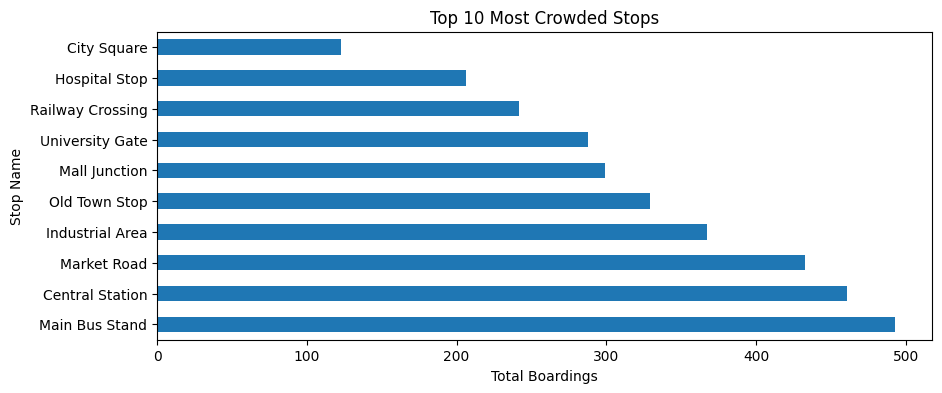

In [10]:
stop_load.plot(kind='barh', figsize=(10,4))
plt.title("Top 10 Most Crowded Stops")
plt.xlabel("Total Boardings")
plt.ylabel("Stop Name")
plt.show()


How Many Stops are there in one trip , which shows the trip with most stops

In [13]:
stops_per_trip = data.groupby('TripID')['StopID'].count().sort_values(ascending=False)
stops_per_trip


,StopID
TripID,
30067,4
30004,3
30092,3
30135,3
30019,3
...,...
30124,1
30140,1
30143,1


then we finally make trip _summary variable where we store value of

1.   Number Of Boarding Per Trip
2.   Number Of Stop Per Trip

and giving columns names for later use



In [15]:
trip_summary = data.groupby('TripID').agg({ 'NumberOfBoardings': 'sum', 'StopID': 'count'})

trip_summary.columns = ['TotalBoardings', 'TotalStops']
trip_summary.head()


,TotalBoardings,TotalStops
TripID,,
30000,57,1
30001,7,1
30004,94,3
30006,37,1
30010,28,1


we get our **Boarding Per Stop** by simple formula

**Total Boarding / Total Stops**

In [16]:
trip_summary['Boardings_per_Stop'] = trip_summary['TotalBoardings'] / trip_summary['TotalStops']

Then We Graphically Show the trip_summary Variable.
Which Shows **Delay Pattern** By 2 factors

1.   Boarding Number
2.   Stops



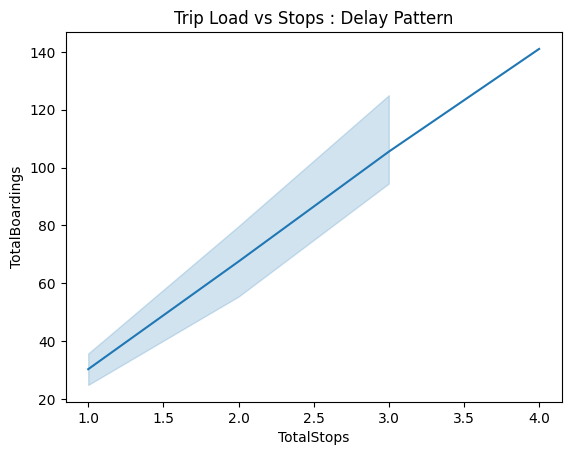

In [18]:
sns.lineplot(data=trip_summary, x='TotalStops', y='TotalBoardings')
plt.title("Trip Load vs Stops : Delay Pattern")
plt.show()
